In [1]:
import cnsplots as cns
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
from lifelines.datasets import load_waltons

cns.setup_matplotlib()
iris = sns.load_dataset("iris")
tips = sns.load_dataset("tips")
fmri = sns.load_dataset("fmri")
waltons = load_waltons()

de_results = pd.read_csv("DE_results.csv", index_col=0)

blobs = sc.datasets.blobs()
blobs.obs["mitf"] = np.random.random(blobs.shape[0])
blobs.var["ensemble"] = [f"ens{x}" for x in np.random.randint(0, 3, blobs.shape[1])]
blobs.obs["selected"] = np.where(blobs.obs["mitf"] > 0.95, blobs.obs["mitf"].index, None)

discrete = sc.AnnData(pd.DataFrame(np.random.randint(0,3,size=(20, 8))))
discrete.var['ensemble'] = [f"ens{x}" for x in np.random.randint(0, 3, discrete.shape[1])]
discrete.obs['mitf'] = [f"gene{x}" for x in np.random.randint(0, 3, discrete.shape[0])]

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
1 ['305', '30', '394', '341', '69']
1 ['4', '3', '5', '1', '8']


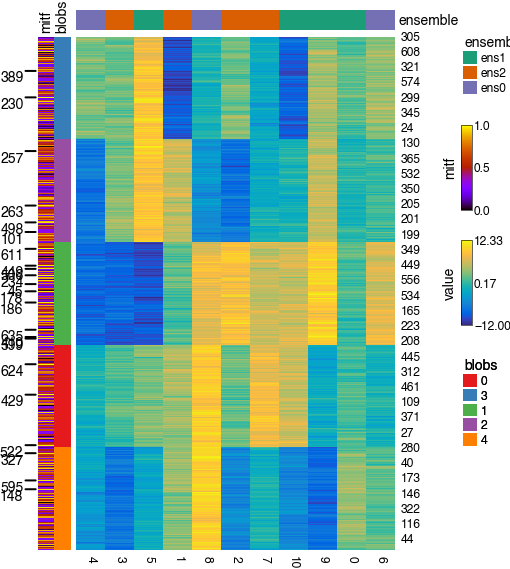

In [29]:
cns.figure(300, 250)
cmp = cns.heatmap(
    blobs,
    row_annotation=["selected", "mitf", "blobs"],
    col_annotation=["ensemble"],
    # row_split=5,  # FIXME: it doesn't split rows properly!!
    # col_split=2,
    # row_split="blobs",
    # col_split=["ensemble"],
    row_cluster=True,
    col_cluster=True,
    row_cluster_method="ward",
    row_cluster_metric="euclidean",
    col_cluster_method="ward",
    col_cluster_metric="euclidean",
    show_rownames=True,
    show_colnames=True,
    row_dendrogram=False,
    col_dendrogram=False,
    row_split_gap=1,
    col_split_gap=1,
    # vmin=0,
    # vmax=1,
)
print(len(cmp.row_order), cmp.row_order[0][:5])
print(len(cmp.col_order), cmp.col_order[0][:5])
plt.savefig("../../../Desktop/salam.pdf")

Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..
Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..


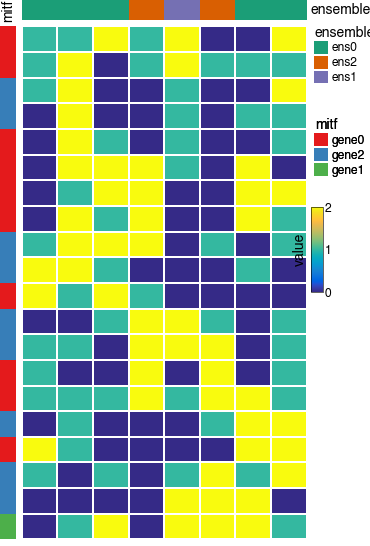

In [43]:
cns.figure(300, 200)
cns.heatmap(
    discrete,
    row_annotation=["mitf"],
    col_annotation=["ensemble"],
    linewidth=1,
)
plt.savefig("../../../Desktop/salam.pdf")

Text(0, 0.5, 'ylabel')

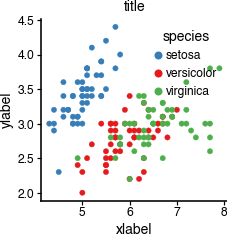

In [2]:
cns.figure(120, 120)
sns.scatterplot(data=iris, x="sepal_length", y="sepal_width", s=7, hue='species', edgecolor=None)
plt.title('title')
plt.xlabel('xlabel')
plt.ylabel('ylabel')
# plt.savefig('../../../Desktop/salam.pdf')

Boxplots represent the median and bottom and upper quartiles; whiskers correspond to 1.5 times the interquartile range.
Boxplots represent the median and bottom and upper quartiles; whiskers correspond to 1.5 times the interquartile range.
setosa vs. versicolor: Mann-Whitney-Wilcoxon test two-sided, P_val:2.143e-13 U_stat=2.312e+03
versicolor vs. virginica: Mann-Whitney-Wilcoxon test two-sided, P_val:4.572e-03 U_stat=8.410e+02
setosa vs. virginica: Mann-Whitney-Wilcoxon test two-sided, P_val:7.100e-09 U_stat=2.086e+03
P values were determined by two-sided Mann-Whitney U test.
Boxplots represent the median and bottom and upper quartiles; whiskers correspond to 1.5 times the interquartile range.
Thur_Male vs. Fri_Male: Mann-Whitney-Wilcoxon test two-sided, P_val:9.378e-01 U_stat=1.470e+02
P values were determined by two-sided Mann-Whitney U test.


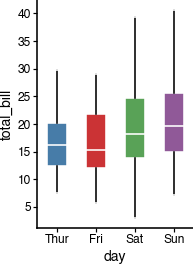

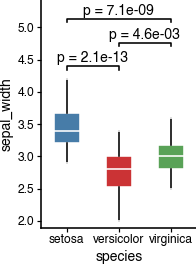

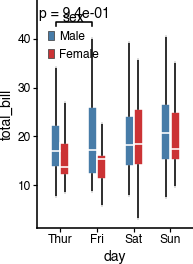

In [3]:
cns.figure(150, 100)
cns.boxplot(data=tips, x="day", y="total_bill")
cns.figure(150, 100)
cns.boxplot(data=iris, x="species", y="sepal_width", pairs="all")
cns.figure(150, 100)
cns.boxplot(data=tips, x="day", y="total_bill", hue="sex", pairs=[(("Thur", "Male"), ("Fri", "Male"))])
# plt.savefig('../../../Desktop/salam.pdf')

Sat vs. Sun: Welch's t-test independent samples, P_val:5.007e-01 t=-6.750e-01
Fri vs. Sat: Welch's t-test independent samples, P_val:1.383e-01 t=-1.524e+00
Thur vs. Fri: Welch's t-test independent samples, P_val:8.068e-01 t=2.468e-01
Fri vs. Sun: Welch's t-test independent samples, P_val:5.797e-02 t=-1.974e+00
Thur vs. Sat: Welch's t-test independent samples, P_val:5.518e-02 t=-1.933e+00
Thur vs. Sun: Welch's t-test independent samples, P_val:9.901e-03 t=-2.616e+00
P values were determined by two-sided Welch's t-test.
setosa vs. versicolor: Welch's t-test independent samples, P_val:2.484e-15 t=9.455e+00
versicolor vs. virginica: Welch's t-test independent samples, P_val:1.819e-03 t=-3.206e+00
setosa vs. virginica: Welch's t-test independent samples, P_val:4.571e-09 t=6.450e+00
P values were determined by two-sided Welch's t-test.
Thur_Male vs. Fri_Male: Welch's t-test independent samples, P_val:7.486e-01 t=-3.274e-01
P values were determined by two-sided Welch's t-test.


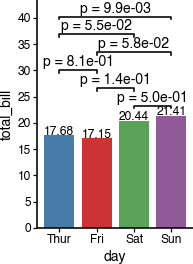

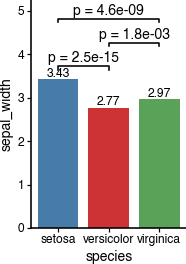

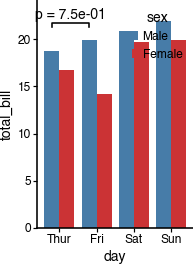

In [4]:
cns.figure(150, 100)
cns.barplot(data=tips, x="day", y="total_bill", pairs="all", addtip=True)
cns.figure(150, 100)
cns.barplot(data=iris, x="species", y="sepal_width", pairs="all", addtip=True)
cns.figure(150, 100)
cns.barplot(data=tips, x="day", y="total_bill", hue="sex", pairs=[(("Thur", "Male"), ("Fri", "Male"))])
# plt.savefig('../../../Desktop/salam.pdf')

P values were determined by two-sided Fisher's exact test
P values were determined by two-sided Fisher's exact test


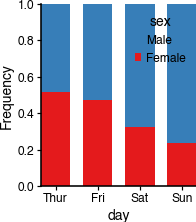

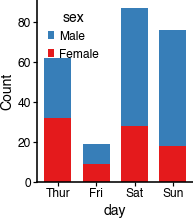

In [17]:
cns.figure(120, 100)
cns.stackplot(data=tips, x='day', hue='sex', normalize=True)
cns.figure(120, 100)
cns.stackplot(data=tips, x='day', hue='sex', normalize=False)
# cns.figure(120, 100)
# cns.stackplot(data=tips, x='day', hue='sex', normalize=True, pairs=[(("Thur", "Male"), ("Fri", "Male"))])
# plt.savefig('../../../Desktop/salam.pdf')

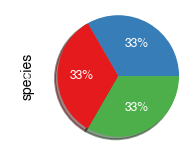

In [6]:
cns.figure(100, 100)
cns.piechart(iris, "species")
# plt.savefig('../../../Desktop/salam.pdf')

<AxesSubplot: xlabel='sepal_length', ylabel='sepal_width'>

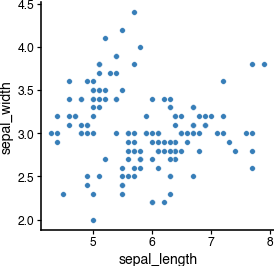

In [7]:
cns.figure(150, 150)
sns.scatterplot(data=iris, x="sepal_length", y="sepal_width", s=8)
# plt.savefig('../../../Desktop/salam.pdf')

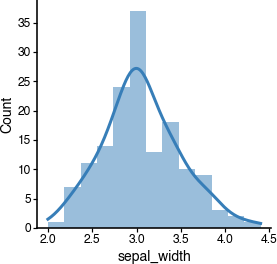

In [8]:
cns.figure(150, 150)
cns.distplot(data=iris, x="sepal_width")
# plt.savefig('../../../Desktop/salam.pdf')

<AxesSubplot: xlabel='sepal_length', ylabel='sepal_width'>

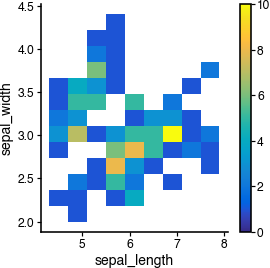

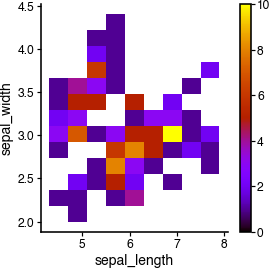

In [9]:
cns.figure(150, 150)
sns.histplot(data=iris, x="sepal_length", y="sepal_width", cbar=True, cmap='parula')
cns.figure(150, 150)
sns.histplot(data=iris, x="sepal_length", y="sepal_width", cbar=True, cmap='gnuplot')
# plt.savefig('../../../Desktop/salam.pdf')

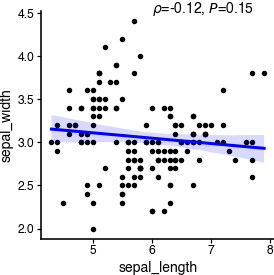

In [10]:
cns.figure(150, 150)
cns.regplot(data=iris, x="sepal_length", y="sepal_width")
# plt.savefig('../../../Desktop/salam.pdf')

P-value was determined by two-sided log-rank test.


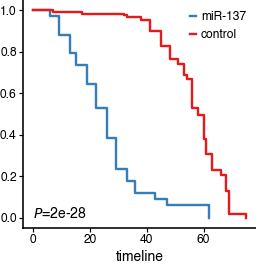

In [11]:
cns.figure(150, 150)
cns.survivalplot(data=waltons, duration="T", event="E", hue="group")
# plt.savefig('../../../Desktop/salam.pdf')

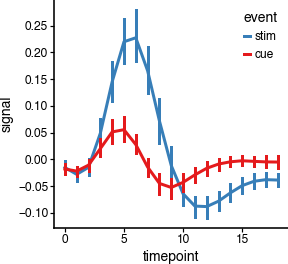

In [30]:
cns.figure(150, 150)
sns.lineplot(data=fmri, x="timepoint", y="signal", hue="event", err_style="bars")
# plt.savefig('../../../Desktop/salam.pdf')

{'matrix': <AxesSubplot: >,
 'shading': <AxesSubplot: >,
 'totals': <AxesSubplot: >,
 'intersections': <AxesSubplot: ylabel='Intersection size'>}

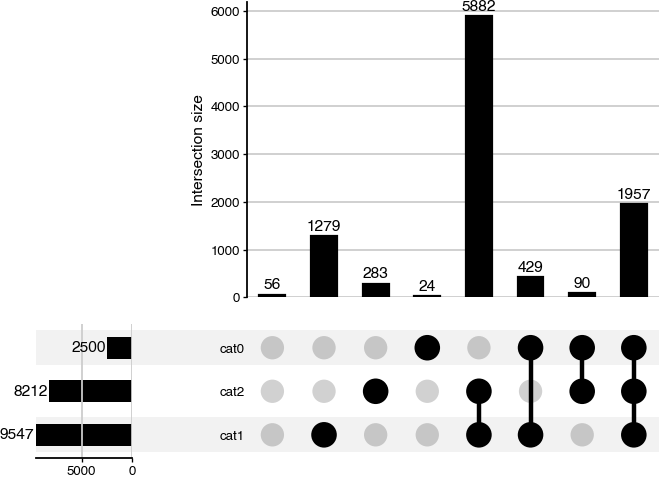

In [13]:
from upsetplot import generate_counts
from upsetplot import plot
example = generate_counts()
plot(example, element_size=30, show_counts=True)
# plt.savefig('../../../Desktop/salam.pdf')

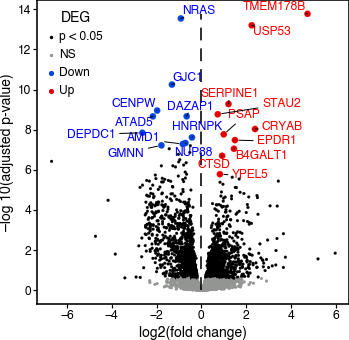

In [42]:
de_results["-log10(adjp)"] = -np.log10(de_results["padj"])
de_results['DEG'] = 'NS'
de_results.loc[de_results['pvalue'] < 0.05, 'DEG'] = 'p < 0.05'
de_results.loc[de_results.loc[(de_results['pvalue'] < 0.05) & (de_results['log2FoldChange'] > 0)].nlargest(10, "-log10(adjp)").index, 'DEG'] = 'Up'
de_results.loc[de_results.loc[(de_results['pvalue'] < 0.05) & (de_results['log2FoldChange'] < 0)].nlargest(10, "-log10(adjp)").index, 'DEG'] = 'Down'

cns.figure(200, 200)
cns.volcanoplot(de_results, x="log2FoldChange", y="-log10(adjp)", hue="DEG", symbol="symbol")
# plt.savefig("../../../Desktop/salam.pdf")